In [56]:
import pandas as pd
import ydata_profiling as pp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [57]:
df = pd.read_csv('../data/mall_customers.csv')

In [58]:
pp.ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 558.85it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [59]:
#keep only the relevant columns for clustering
df = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [60]:
print(df)

     Annual Income (k$)  Spending Score (1-100)
0                    15                      39
1                    15                      81
2                    16                       6
3                    16                      77
4                    17                      40
..                  ...                     ...
195                 120                      79
196                 126                      28
197                 126                      74
198                 137                      18
199                 137                      83

[200 rows x 2 columns]


In [61]:
#scaling the features for clustering
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# MODELING AND PLOTTING FOR KMEANS


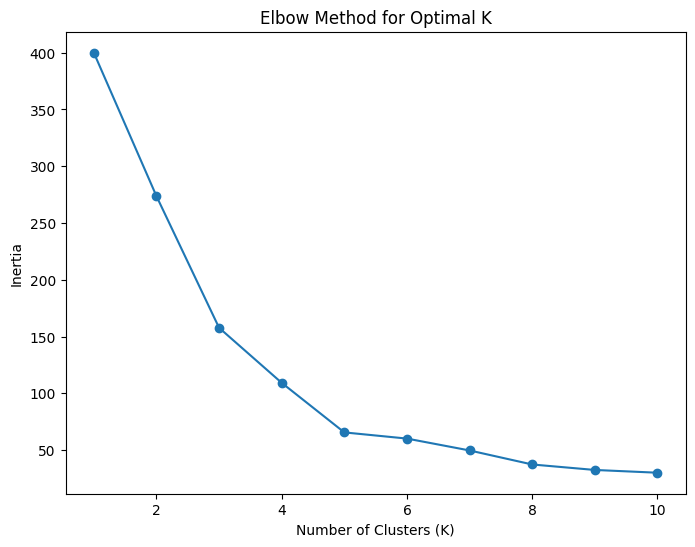

In [62]:
#determining the optimal number of clusters using the elbow method

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K_range, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

Silhouette Score for KMeans: 0.55


C:\Users\User\AppData\Local\Temp\ipykernel_31764\396350179.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cluster'] = kmeans.labels_


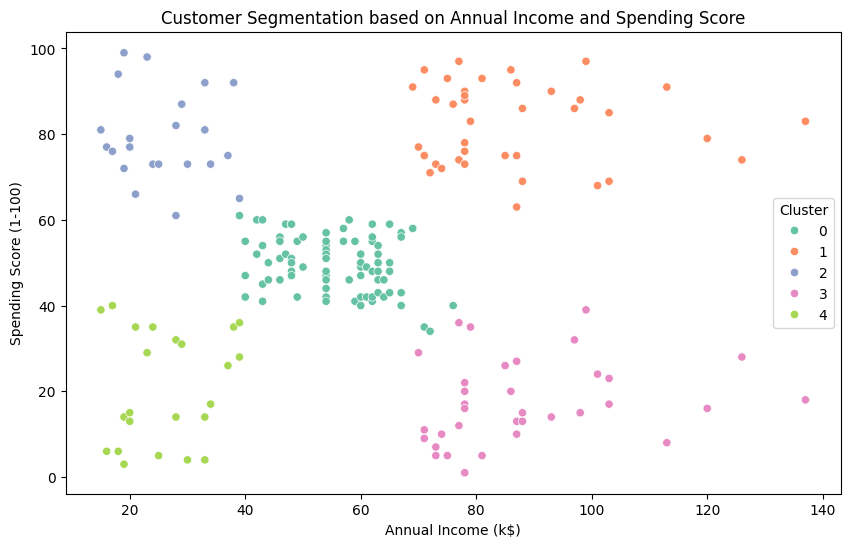

C:\Users\User\AppData\Local\Temp\ipykernel_31764\396350179.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('Cluster', axis=1, inplace=True)


In [63]:
#model training and evaluation
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(df)
silhouette_avg = silhouette_score(df, kmeans.labels_)
print(f'Silhouette Score for KMeans: {silhouette_avg:.2f}')


#cluster plotting
df['Cluster'] = kmeans.labels_
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set2')
plt.title('Customer Segmentation based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()
df.drop('Cluster', axis=1, inplace=True)

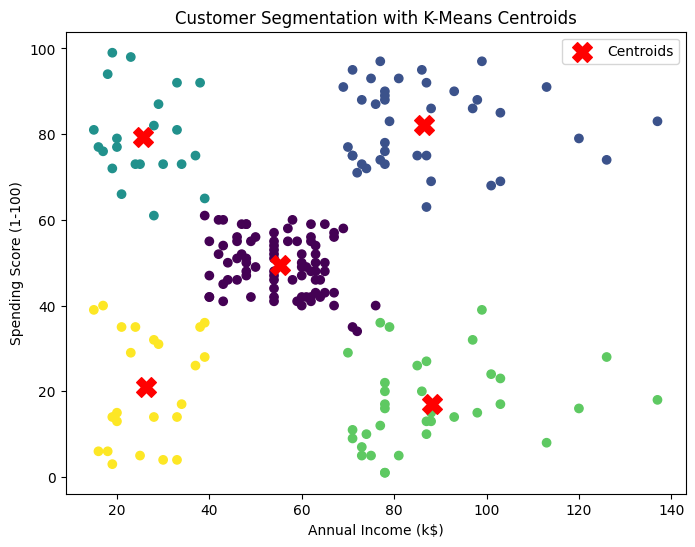

In [64]:
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=kmeans.labels_,
    cmap="viridis"
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    color="red",
    s=200,
    marker="X",
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation with K-Means Centroids")
plt.legend()
plt.show()

# MODELING AND PLOTTING FOR DBSCAN

Silhouette Score for DBSCAN: 0.42


C:\Users\User\AppData\Local\Temp\ipykernel_31764\908896753.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DBSCAN_Cluster']= DBSCAN_model.labels_


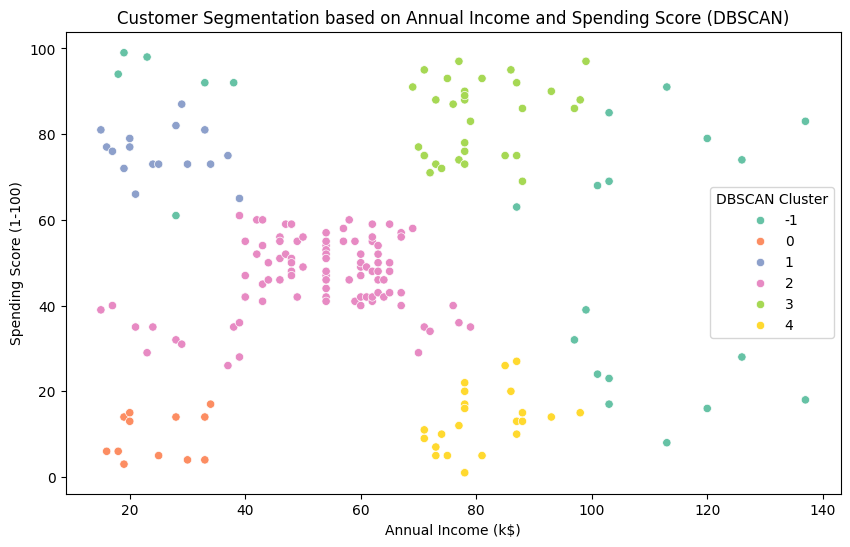

In [68]:
DBSCAN_model = DBSCAN(eps=10, min_samples=7)
DBSCAN_model.fit(df)
silhouette_avg_dbscan = silhouette_score(df, DBSCAN_model.labels_)
print(f'Silhouette Score for DBSCAN: {silhouette_avg_dbscan:.2f}')

df['DBSCAN_Cluster']= DBSCAN_model.labels_
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', palette='Set2')
plt.title('Customer Segmentation based on Annual Income and Spending Score (DBSCAN)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='DBSCAN Cluster')
plt.show()

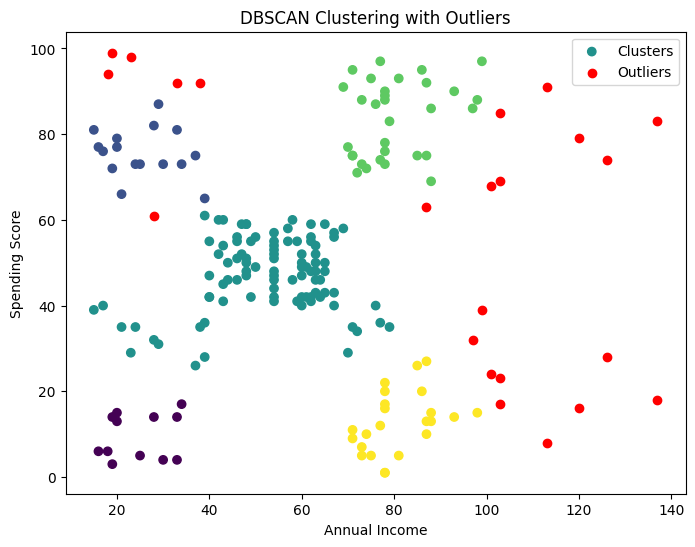

In [69]:
labels = DBSCAN_model.labels_

plt.figure(figsize=(8,6))

# pontos normais
plt.scatter(
    df[labels != -1]["Annual Income (k$)"],
    df[labels != -1]["Spending Score (1-100)"],
    c=labels[labels != -1],
    cmap="viridis",
    label="Clusters"
)

# outliers
plt.scatter(
    df[labels == -1]["Annual Income (k$)"],
    df[labels == -1]["Spending Score (1-100)"],
    color="red",
    label="Outliers"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("DBSCAN Clustering with Outliers")
plt.legend()

plt.show()